In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Importing Libraries**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
zip_file_path = '/content/drive/MyDrive/Airbnb_Open_Data.zip'

In [ ]:
import zipfile
import os
extraction_dir = '/content/drive/MyDrive/Airbnb_Extracted_Data'
os.makedirs(extraction_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)
    print(f"Files extracted to {extraction_dir}")
extracted_files = os.listdir(extraction_dir)
print("Extracted Files:", extracted_files)

Files extracted to /content/drive/MyDrive/Airbnb_Extracted_Data
Extracted Files: ['Airbnb_Open_Data.csv']


**Loading the Dataset:**

In [ ]:
csv_file_path = '/content/drive/MyDrive/Airbnb_Extracted_Data/Airbnb_Open_Data.csv'
df = pd.read_csv(csv_file_path)



<ipython-input-15-ae1e7b84a861>:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file_path)


In [ ]:
print(df.head(3))


        id                                 NAME      host id  \
0  1001254   Clean & quiet apt home by the park  80014485718   
1  1002102                Skylit Midtown Castle  52335172823   
2  1002403  THE VILLAGE OF HARLEM....NEW YORK !  78829239556   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73.97237  United States  ...       $193            10.0   
1  40.75362 -73.98377  United States  ...        $28            30.0   
2  40.80902 -73.94190  United States  ...       $124             3.0   

  number of reviews last review  reviews per month review rate number  \
0               9.0  10/19/2021               0.21                4.0   
1              45.0

In [ ]:
df.shape
print ("Number of rows in DataFrame are:", df.shape[0])
print("Number of columns in DataFrame are:", df.shape[1])

Number of rows in DataFrame are: 102599
Number of columns in DataFrame are: 26


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [ ]:
df.describe()

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


**Checking for missing values**

In [ ]:
df.isnull().sum()

,0
host_identity_verified,0
neighbourhood group,0
neighbourhood,0
lat,8
long,8
instant_bookable,0
cancellation_policy,0
room type,0
Construction year,214
price,247


In [ ]:
df.columns #columns in data frame

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

# **Data Cleaning:**

**Dropping Unnecessary Columns:**

In [ ]:
columns = ['id', 'host id', 'NAME', 'host name', 'license', 'house_rules', 'last review', 'country', 'country code']
df = df.drop(columns=columns, axis=1)



In [ ]:
df.head(3)

,host_identity_verified,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
0,unconfirmed,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020.0,$966,$193,10.0,9.0,0.21,4.0,6.0,286.0
1,verified,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,0.38,4.0,2.0,228.0
2,NaN,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,5.0,1.0,352.0


**Converting price and service fee columns to numeric datatype:**

In [ ]:
# Remove dollar signs and commas, strip whitespace, and convert to float
df['price'] = df['price'].str.replace(',', '', regex=True).str.lstrip('$').astype(float)
df['service fee'] = df['service fee'].str.replace(',', '', regex=True).str.lstrip('$').astype(float
print(df[['price', 'service fee']].head())


   price  service fee
0  966.0        193.0
1  142.0         28.0
2  620.0        124.0
3  368.0         74.0
4  204.0         41.0


In [ ]:
print(df[['price', 'service fee']].isnull().sum())


price          247
service fee    273
dtype: int64


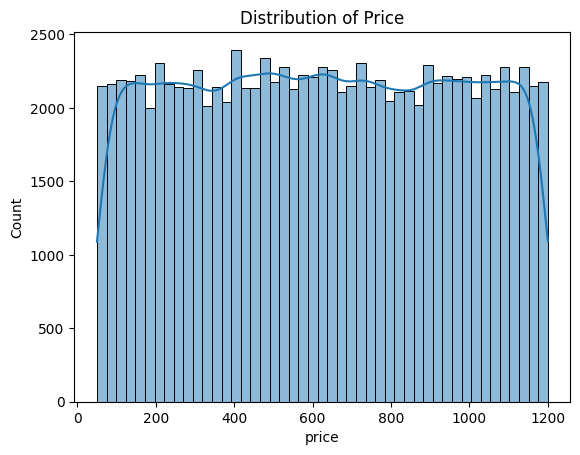

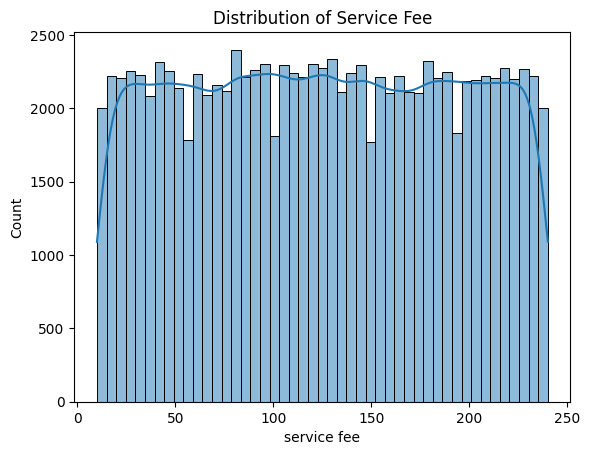

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of price
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Price')
plt.show()

# Plot distribution of service fee
sns.histplot(df['service fee'], kde=True)
plt.title('Distribution of Service Fee')
plt.show()


**Filling missing values in Price and Service fee columns:**

In [ ]:
# Impute missing values using mean
df['price'] = df['price'].fillna(df['price'].mean())
df['service fee'] = df['service fee'].fillna(df['service fee'].mean())
print(df[['price', 'service fee']].isnull().sum())


price          0
service fee    0
dtype: int64


**Removing Duplicates:**

In [ ]:
# Check for duplicate rows
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")



Number of duplicate rows: 3636


In [ ]:
# Drop duplicate rows
df = df.drop_duplicates()
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")


Number of duplicate rows after dropping: 0


In [ ]:
null_values = df.isnull().sum()
print("Missing values per column:")
print(null_values)



Missing values per column:
host_identity_verified              289
neighbourhood group                  29
neighbourhood                        16
lat                                   8
long                                  8
instant_bookable                    105
cancellation_policy                  76
room type                             0
Construction year                   214
price                                 0
service fee                           0
minimum nights                      398
number of reviews                   180
reviews per month                 15338
review rate number                  313
calculated host listings count      308
availability 365                    448
dtype: int64

Columns with missing values:
host_identity_verified              289
neighbourhood group                  29
neighbourhood                        16
lat                                   8
long                                  8
instant_bookable                    105
cancellati

**Filling Missing Values in Categorical Columns:**

In [ ]:
# Impute missing categorical columns with  mode
df['host_identity_verified'] = df['host_identity_verified'].fillna(df['host_identity_verified'].mode()[0])
df['neighbourhood group'] = df['neighbourhood group'].fillna(df['neighbourhood group'].mode()[0])
df['neighbourhood'] = df['neighbourhood'].fillna(df['neighbourhood'].mode()[0])
df['instant_bookable'] = df['instant_bookable'].fillna(df['instant_bookable'].mode()[0])
df['cancellation_policy'] = df['cancellation_policy'].fillna(df['cancellation_policy'].mode()[0])


<ipython-input-20-919c92aadec7>:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['instant_bookable'] = df['instant_bookable'].fillna(df['instant_bookable'].mode()[0])


In [ ]:
# Dropping the 'reviews per month' column as it has significant nulls
df = df.drop(columns=['reviews per month'], axis=1)
print(df.head())


  host_identity_verified neighbourhood group neighbourhood       lat  \
0            unconfirmed            Brooklyn    Kensington  40.64749   
1               verified           Manhattan       Midtown  40.75362   
2            unconfirmed           Manhattan        Harlem  40.80902   
3            unconfirmed            Brooklyn  Clinton Hill  40.68514   
4               verified           Manhattan   East Harlem  40.79851   

       long  instant_bookable cancellation_policy        room type  \
0 -73.97237             False              strict     Private room   
1 -73.98377             False            moderate  Entire home/apt   
2 -73.94190              True            flexible     Private room   
3 -73.95976              True            moderate  Entire home/apt   
4 -73.94399             False            moderate  Entire home/apt   

   Construction year  price  service fee  minimum nights  number of reviews  \
0             2020.0  966.0        193.0            10.0           

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
host_identity_verified,0
neighbourhood group,0
neighbourhood,0
lat,0
long,0
instant_bookable,0
cancellation_policy,0
room type,0
Construction year,0
price,0


In [ ]:
df.shape #after dropping nulls

(97658, 16)

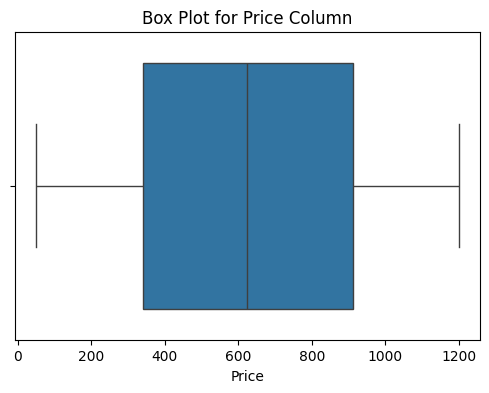

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])

# Show the plot
plt.title('Box Plot for Price Column')
plt.xlabel('Price')
plt.show()


In [ ]:
df.columns

Index(['host_identity_verified', 'neighbourhood group', 'neighbourhood', 'lat',
       'long', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'review rate number',
       'calculated host listings count', 'availability 365'],
      dtype='object')

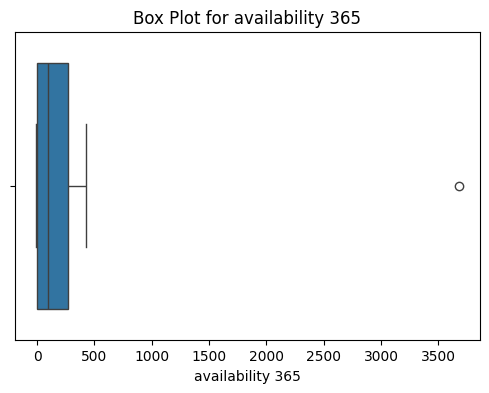

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Create the box plot for the 'price' column
plt.figure(figsize=(6,4))
sns.boxplot(x=df['availability 365'])

# Show the plot
plt.title('Box Plot for availability 365')
plt.xlabel('availability 365')
plt.show()


The box plot shows the presence of an oulier which should be removed.

In [ ]:
# Filter out values greater than 3500
df= df[df['availability 365'] <= 3500]

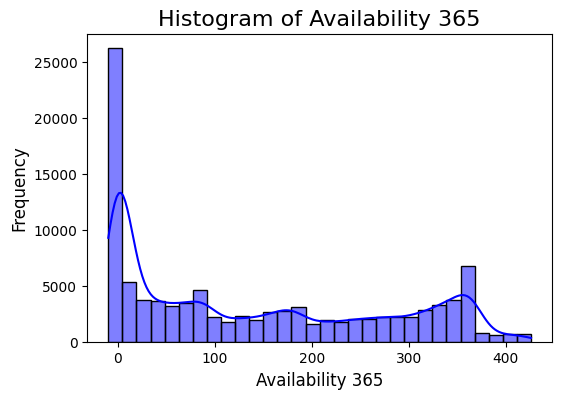

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='availability 365', bins=30, kde=True, color='blue')
plt.title('Histogram of Availability 365', fontsize=16)
plt.xlabel('Availability 365', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


**Room Type** **Distribution**

<ipython-input-25-e1b9c3764660>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='room type', palette='viridis')


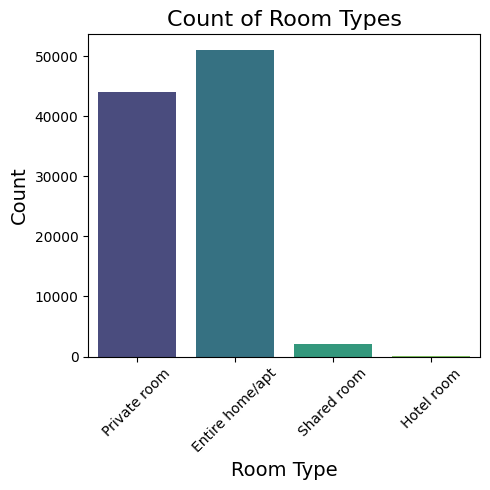

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='room type', palette='viridis')
plt.title('Count of Room Types', fontsize=16)
plt.xlabel('Room Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The count plot shows the distribution of different room types available in the dataset. Each bar represents the number of listings for a specific room type. This visualization helps us understand which room types are more common and how they compare to each other in terms of availability.

**Number of Listings by Neighborhood Group**

<ipython-input-24-fb79547c21b2>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='neighbourhood group', palette='viridis')


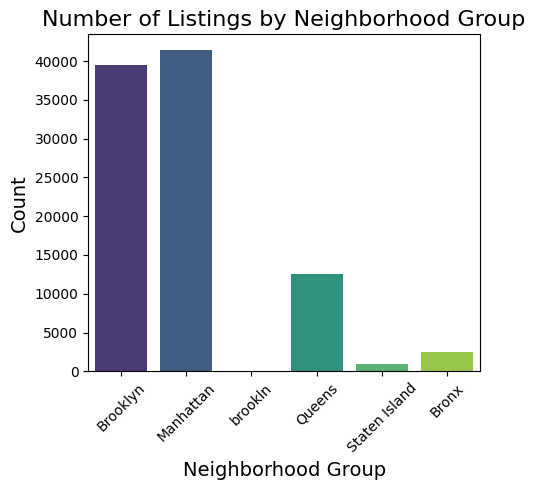

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='neighbourhood group', palette='viridis')
plt.title('Number of Listings by Neighborhood Group', fontsize=16)
plt.xlabel('Neighborhood Group', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


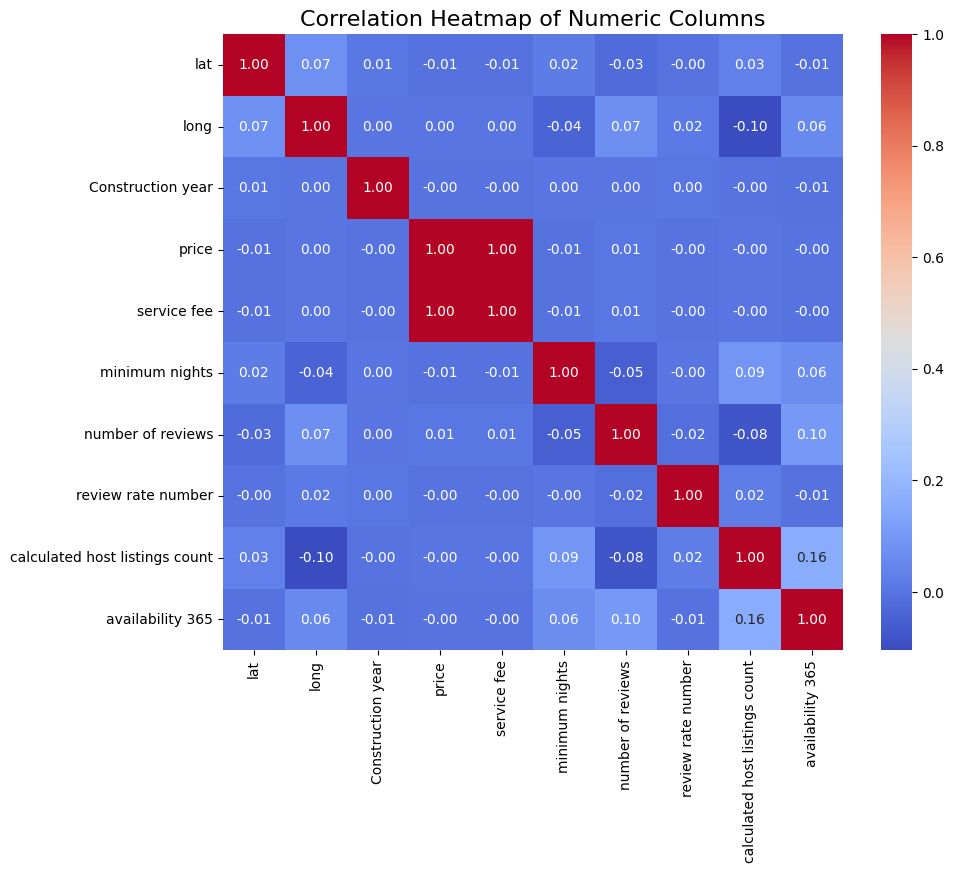

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['number'])
correlation_matrix = numeric_cols.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Numeric Columns', fontsize=16)
plt.show()
